In [17]:
from evolution import time_evolve, animate
from scipy.special import gamma
import numpy as np
import matplotlib.pyplot as plt

In [18]:
lam = 100
# x0, p0 = np.arctan(np.sqrt(lam + 0.25)/lam), 0
x0, p0 = 0, np.sqrt(lam + 0.25)
max_V = 1000

eps = 1
domain = np.linspace(-np.pi/2 - eps, np.pi/2 + eps, 100, dtype=np.complex128)
dx = np.abs(domain[1] - domain[0])

Vx = lam * (lam - 1) / np.cos(domain) ** 2 - lam**2
Vx = Vx.clip(None, max_V)

c = np.sqrt(gamma(lam+1)/(np.sqrt(np.pi) * gamma(lam + 0.5)))
psi_0 = c * (np.cos(domain - x0) ** lam)
psi_0 *= np.exp(1j * p0 * domain)

Vx[domain < -np.pi/2] = Vx[domain < -np.pi/2][-1]
Vx[domain > np.pi/2] = Vx[domain > np.pi/2][0]

psi_0[domain < -np.pi/2] = 0
psi_0[domain > np.pi/2] = 0

In [19]:
max_t = 10
dt = 0.5 * dx ** 2
T = int(max_t / dt) + 1
results = time_evolve(domain, psi_0, Vx, max_t, it=T)

100%|██████████| 7416/7416 [00:00<00:00, 12050.47it/s]


In [20]:
t_eval = np.array(results['t'])
E_q = np.array(results['T']) + np.array(results['V'])

In [21]:
def x_exact(t, x0, p0, lam):
    E = p0**2 + lam**2 * np.tan(x0)**2
    phi = np.arcsin(np.sqrt((E + lam**2)/E) * np.sin(x0))
    if p0 < 0:
        phi = np.pi - phi
    period = np.pi / np.sqrt(E + lam**2)
    print(f"Classical period = {period:.3f}")
    return np.arcsin(np.sqrt(E/(E + lam**2)) * np.sin(2 * np.sqrt(E + lam**2) * t + phi))

def p_exact(t, x0, p0, lam):
    E = p0**2 + lam**2 * np.tan(x0)**2
    phi = np.arcsin(np.sqrt((E + lam**2)/E) * np.sin(x0))
    if p0 < 0:
        phi = np.pi - phi
    
    theta = 2 * np.sqrt(E + lam**2) * t + phi
    return np.sqrt(E * (E + lam**2)) * np.cos(theta) / np.sqrt(E * np.cos(theta)**2 + lam**2)

x_cl = x_exact(t_eval, x0, p0, lam)
p_cl = p_exact(t_eval, x0, p0, lam)
E_cl = p_cl ** 2 + lam**2 * np.tan(x_cl)**2

Classical period = 0.031


In [22]:
# find ts where p_cl is near 0
classical_tp = [t_eval[i] for i in range(len(p_cl)-1) if p_cl[i] * p_cl[i+1] < 0]
V_tp = lam * (lam - 1) / np.cos(results['x']) ** 2 - lam**2
# find all local maximum timestamps
V_tp_diff = np.diff(V_tp)
V_tp_diff2 = np.diff(V_tp_diff)
quantum_tp = [t_eval[i] for i in range(len(V_tp_diff)-1) if V_tp_diff[i] * V_tp_diff[i+1] < 0 and V_tp_diff2[i] < 0]

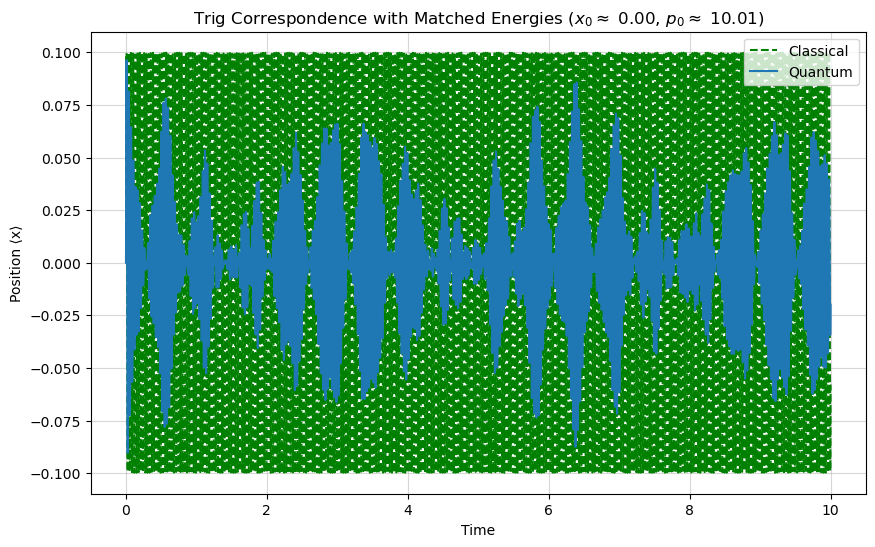

In [23]:
plt.figure(figsize=(10, 6), dpi=100)
plt.plot(t_eval, x_cl, '--', c='g', label='Classical')
plt.plot(t_eval, results['x'], label='Quantum')
plt.title(f'Trig Correspondence with Matched Energies ($x_0\\approx$ {x0:.2f}, $p_0 \\approx$ {p0:.2f})')
plt.ylabel("Position ⟨x⟩")
plt.xlabel("Time")
# plt.vlines(quantum_tp, ymin=min(results['x']), ymax=max(results['x']), colors='r', linestyles='--', alpha=0.7)
plt.grid(True, alpha=0.5)
plt.legend()
plt.show()

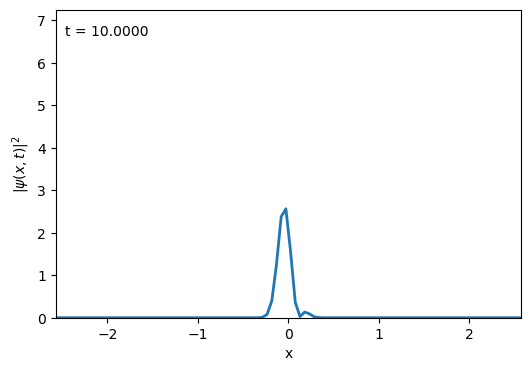

In [ ]:
probs = np.abs(results['psi_avg']) ** 2
# animate(domain.real, probs, max_t, filename="prob.gif")